# SmartCart 
- E-commerce Customer Segmentation System

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

In [6]:
# handle missing values
df["Income"] = df["Income"].fillna(df["Income"].median())

## Feature Engineering

In [7]:
#Converting year_birth to Age
df["Age"] = 2026 - df["Year_Birth"]

- Clustering algorithms don’t inherently understand date data, but they can use it after proper numerical preprocessing. 

In [8]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [9]:
# Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [10]:
# Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [11]:
# Education
df["Education"].value_counts()

df['Education'] = df['Education'].replace({
    'Basic': 'Undergraduate', '2n Cycle': 'Undergraduate',
    'Graduation': 'Graduate',
    'Master': 'Postgraduate', 'PhD': 'Postgraduate'
})

df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [12]:
# Marital_Status
df["Marital_Status"].value_counts()

df['Living_With'] = df['Marital_Status'].replace({
    'Married': 'Partner', 'Together': 'Partner',
    'Single': 'Alone', 'Divorced': 'Alone',
    'Widow': 'Alone', 'Alone': 'Alone',
    'Absurd': 'Alone','YOLO': 'Alone'
})

df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop Columns

In [13]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome" , "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines",  'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [14]:
df_cleaned.shape

(2240, 15)

In [15]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Outliers

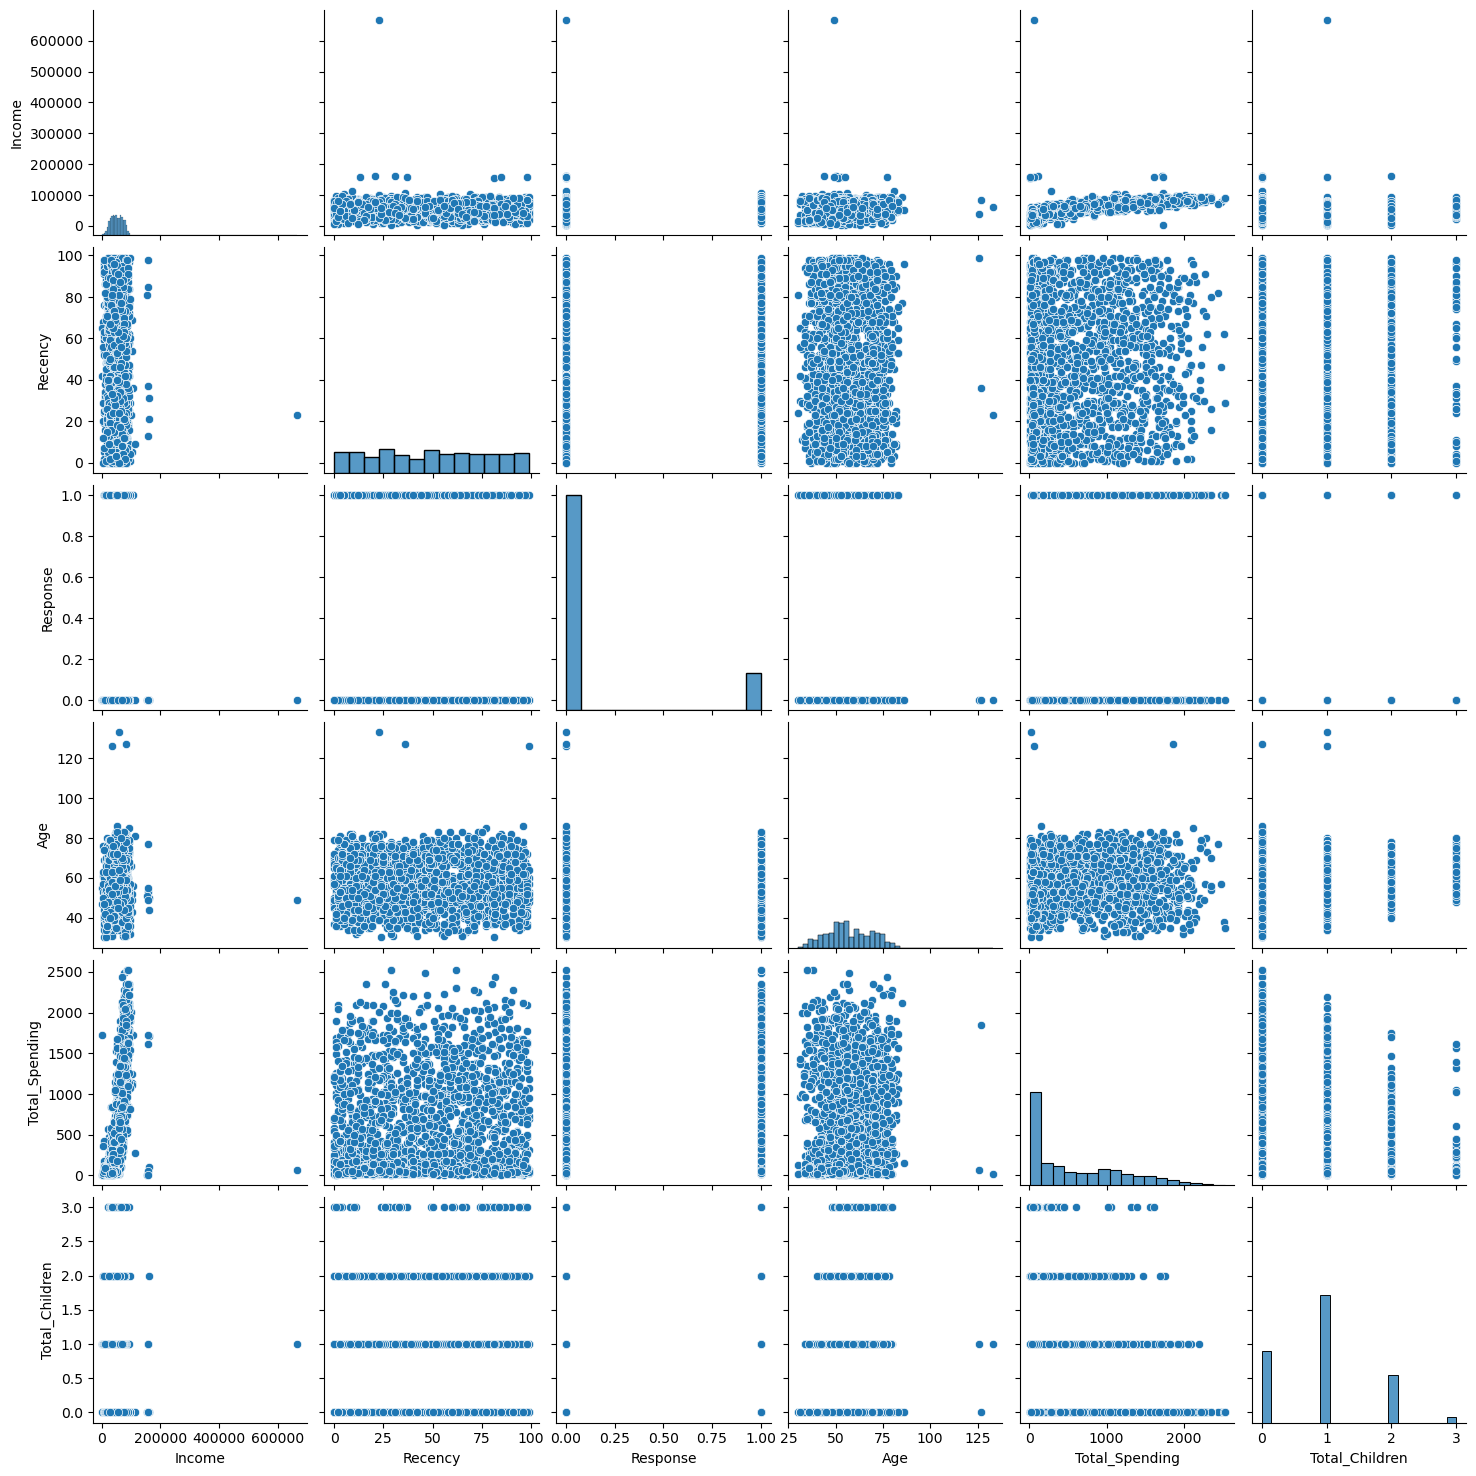

In [16]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features - pair plots
sns.pairplot(df_cleaned[cols])

In [17]:
# Remove Outliers - Income, Age
print("Data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("Data size without outliers:", len(df_cleaned))

Data size with outliers: 2240
Data size without outliers: 2236


## Heatmap

<Axes: >

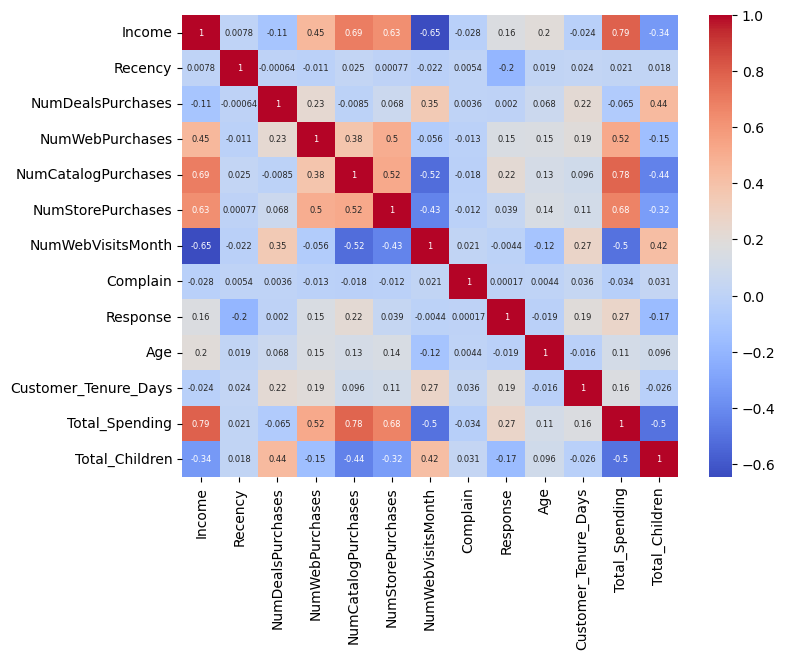

In [18]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize = (8,6))
sns.heatmap(
    corr, 
    annot=True, 
    annot_kws = {"size": 6},
    cmap='coolwarm'
)

## Encoding - One Hot Encoding
- In clustering, we don’t use `drop='first'` in OneHotEncoder because keeping all categories preserves information for distance-based calculations.

In [19]:
ohe = OneHotEncoder()  

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)

df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols), enc_df], axis = 1)

In [20]:
df_encoded.shape

(2236, 18)

In [21]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


## Scaling

In [22]:
X = df_encoded

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Visualize - PCA

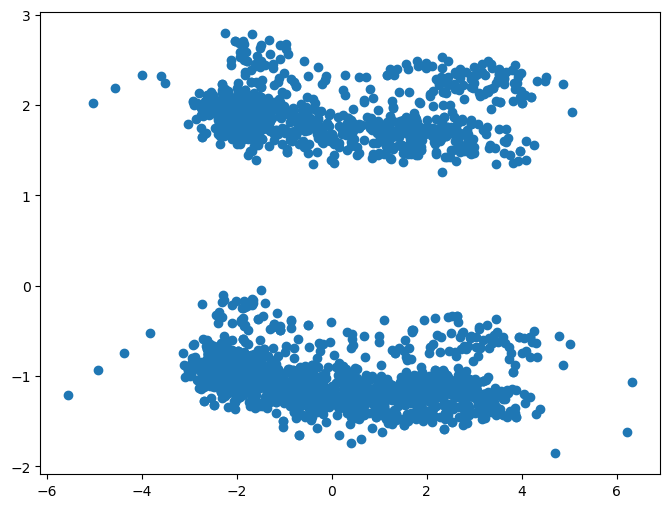

In [24]:
# 2D visualize using PCA
pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize = (8, 6))
plt.scatter(X_pca[:,0], X_pca[:,1])

In [25]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

### The first two principal components explain:

- PC1: 23.16% of the variance
- PC2: 11.39% of the variance
- Total explained variance: 34.5%

This means that only about one-third of the total information in the dataset is captured by these two components, while the remaining ~65% of the variance is still unexplained. Therefore, using only two principal components may not be sufficient to represent the data effectively

In [26]:
# 3D visualize using PCA
pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D Projection')

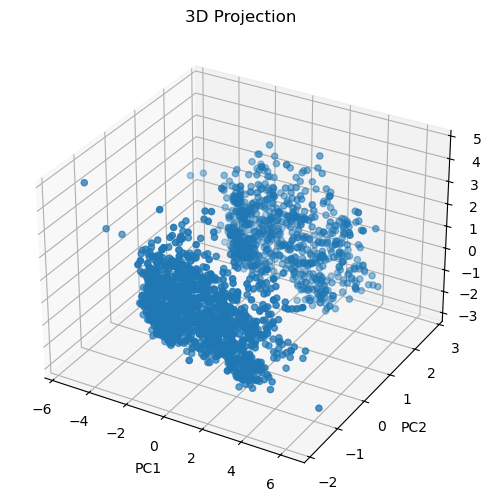

In [27]:
# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projection")

## Analyze K value

### Elbow method & KneeLocator

In [28]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [29]:
knee = KneeLocator(range(1,11), wcss, curve = "convex", direction = "decreasing")
optimal_k = knee.elbow

print("Best k =",optimal_k)

Best k = 4


Text(0, 0.5, 'WCSS')

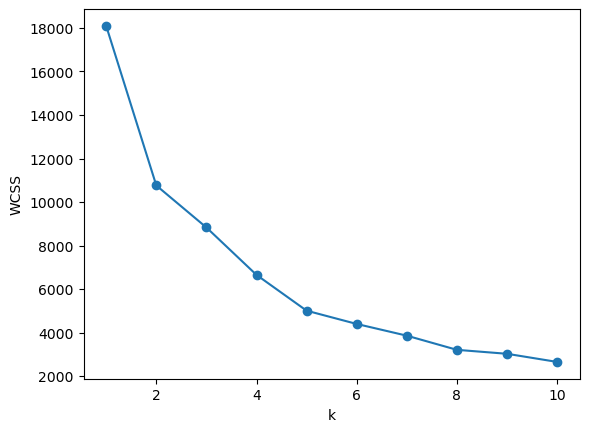

In [30]:
# plot 
plt.plot(range(1,11), wcss, marker = "o")
plt.xlabel("k")
plt.ylabel("WCSS")

### Silhouette Score

Text(0, 0.5, 'Silhouette Score')

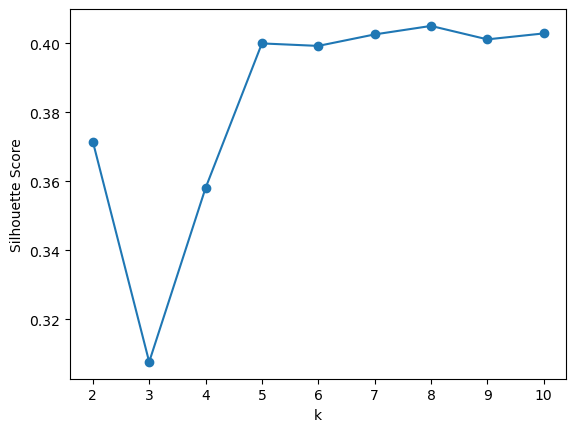

In [31]:
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot 
plt.plot(range(2,11), scores, marker = "o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")

Text(0.5, 1.0, 'Elbow Method & Silhouette Score Comparison')

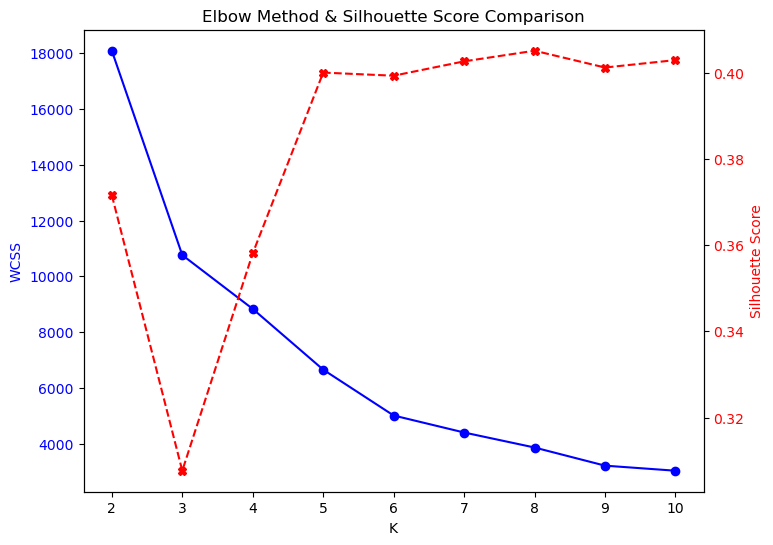

In [32]:
# Combine plot - silhouette score & elbow method
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8,6))

# Elbow method (WCSS)
ax1.plot(k_range, wcss[:len(k_range)], marker = "o", color = "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS", color="blue")
ax1.tick_params(axis='y', labelcolor='blue')

# Silhouette score
ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker = "X", color = "red", linestyle = "--")
ax2.set_ylabel("Silhouette Score", color="red")
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Elbow Method & Silhouette Score Comparison")

# Clustering

In [33]:
# KMeans
kmeans = KMeans(n_clusters = 4, random_state =42)
labels_kmeans = kmeans.fit_predict(X_pca)

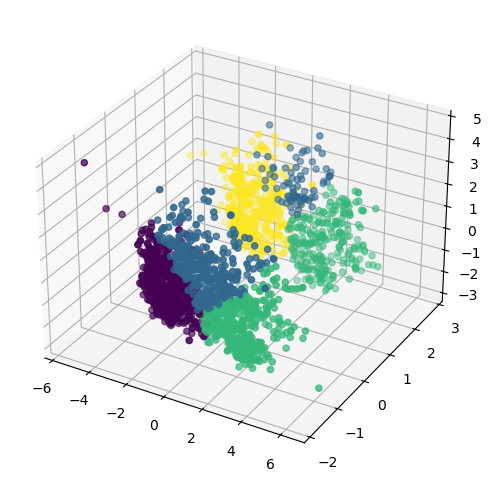

In [34]:
# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = labels_kmeans)

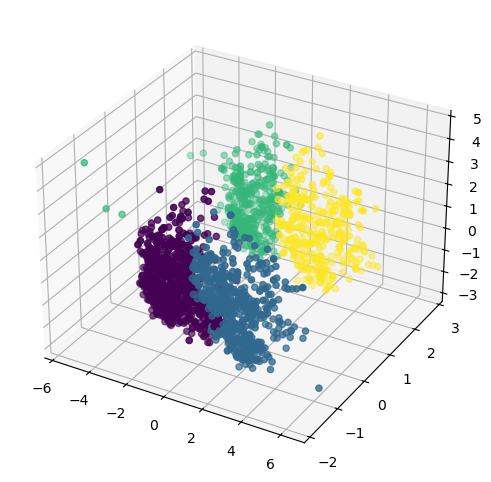

In [35]:
# Agglomerative Clustering
agg_clf = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
labels_agg = agg_clf.fit_predict(X_pca)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = labels_agg)

# Characterization of Clusters

In [36]:
X["cluster"] = labels_agg

In [37]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

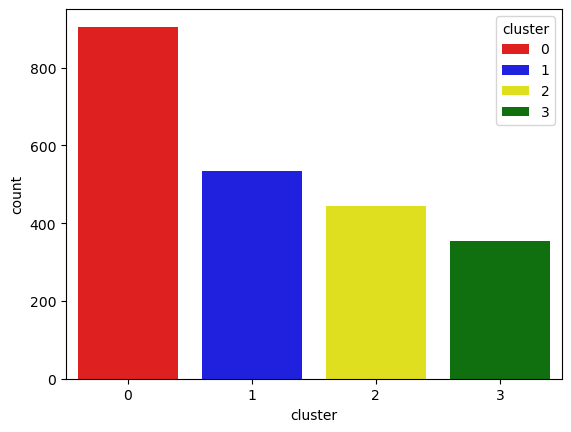

In [38]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette = pal, hue = X["cluster"])


<Axes: xlabel='Total_Spending', ylabel='Income'>

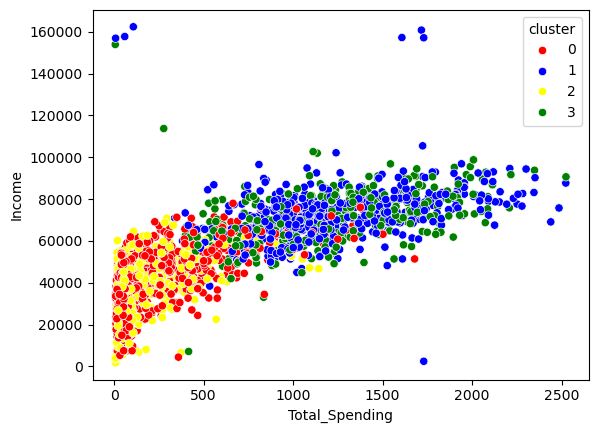

In [39]:
# Income & Spending patterns
sns.scatterplot(x = X["Total_Spending"],y = X["Income"],hue = X["cluster"], palette = pal)

### Cluster 0 : Red
- low / moderate income
- low / moderate spending

### Cluster 1 : Blue
- high income
- high spending

### Cluster 2 : Yellow
- low income
- low spending

### Cluster 3 : Green
- moderate - high income
- high spending

In [40]:
# Cluster Summary
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         

### Cluster 0 : Red
- more children
- poor response
- partner
- web visits high
- store, cat, web purchase low

### Cluster 1 : Blue
- few children
- slightly high age
- avg response
- partner
- web visits low
- store, cat, web purchase high

### Cluster 2 : Yellow
- more children
- avg response
- alone
- web visits high
- store, cat, web purchase very low
  
### Cluster 3 : Green
- few children
- slightly high age
- best response
- alone
- web visits low
- store, cat, web purchase high


### 🔴 Cluster 0: Family Shoppers

Customers in this segment tend to have more children and are usually in a relationship. They show poor campaign response and exhibit high website visit activity but low actual purchases across store, catalog, and web channels. This suggests browsing behavior without strong conversion. These are price-sensitive customers who respond better to **discounts and coupons**.

---

### 🔵 Cluster 1: Loyal, Educated Buyers

This group consists of customers with fewer children and slightly higher age, often with partners and postgraduate education. They have moderate campaign response and low website visits but make high purchases across all channels. These are consistent and valuable customers who can be retained through **loyalty programs and rewards**.

---

### 🟡 Cluster 2: Digital Browsers

Customers here typically have more children and are mostly single. They show average campaign response, high website visits, but very low purchases across all channels. This indicates strong browsing behavior with low conversion. They are highly price-sensitive and may respond to **heavy discounts, sales, and promotional offers**.

---

### 🟢 Cluster 3: High-Value Singles

This segment includes slightly older customers with fewer children who are mostly single. They demonstrate the best campaign response, low website visits, and high purchases across all channels. These are high-value customers with strong buying intent, making them ideal for **premium offerings and personalized services**, delivering the best ROI.